# Network Analysis of the Map of Science
**Author:** Sude Boz  
**Course:** Social Network Analysis - Homework 1  

## Importing libraries

In [ ]:
# loading libraries
import matplotlib.pyplot as plt
import numpy as np
import igraph as ig
import pandas as pd
import collections
import community as community_louvain
import random
from collections import Counter
from scipy.stats import norm
from scipy.stats import gaussian_kde
from scipy.spatial import ConvexHull
from matplotlib.patches import Polygon


ig.set_random_number_generator(random.Random(32))
np.random.seed(32)

In [36]:
# loading the network
G = ig.Graph.Read_GML("MapOfScience.gml")
print(G.summary())

IGRAPH UN-- 687 13046 -- 
+ attr: Class (v), WikipediaUrl (v), id (v), name (v), CosineSimilarity (e)


In [37]:
# simplify
G.simplify()
print(G.summary())

IGRAPH UN-- 687 6523 -- 
+ attr: Class (v), WikipediaUrl (v), id (v), name (v)


# Exploring Nodes and Edges

In [38]:
print(G.vertex_attributes()) # listing node attribute names
print(G.edge_attributes()) # listing edge atribute names
print(G.vs["name"][:6]) #first 6 node names
print(Counter(G.vs["Class"])) # count of each class

['id', 'name', 'Class', 'WikipediaUrl']
[]
['Accounting', 'Aerospace engineering', 'Agricultural engineering', 'Agricultural science', 'Agronomy', 'Algaculture']
Counter({'Social': 229, 'Formal': 193, 'Natural': 171, 'Applied': 94})


`id` — numeric node ID

`name` — the Wikipedia page name (e.g., Accounting, Aerospace engineering)

`Class` — what category each field belongs to (like "Formal sciences", "Natural sciences", etc.). This is extremely useful for Q5 — you can compare your detected communities against these "ground truth" classes and see how well Louvain recovered them.

`WikipediaUrl` — URL to the page

`CosineSimilarity` — the actual similarity value on each edge. The graph is listed as unweighted, but the raw similarities are right there if you want them later.

# Network Visualization

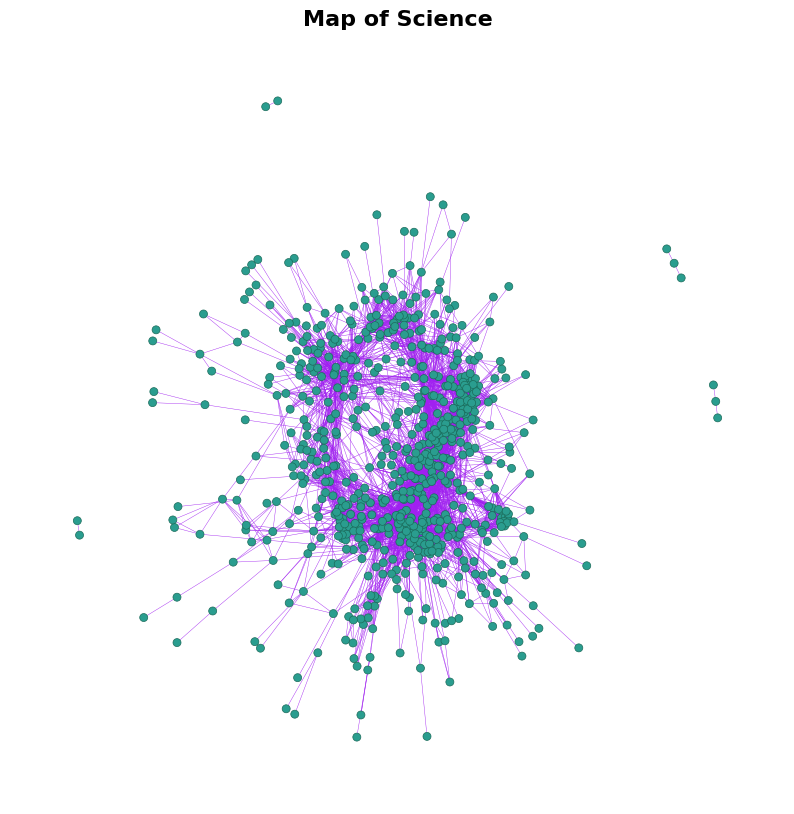

In [61]:
# Network Visualization
fig, ax = plt.subplots(figsize=(10, 10))
ig.plot(G, target=ax,
        vertex_size=8,
        vertex_label=None,
        vertex_color="#2A9D8F",
        vertex_frame_color="#1B6B5A",
        vertex_frame_width=0.5,
        edge_color="purple",
        edge_width=0.3)
plt.title("Map of Science", fontsize=16, fontweight='bold')
plt.show()

# Q1

- Describe the network in 1 or 2 lines.

- What do the nodes and edges represent?

- What is the number of nodes and links?

- What’s the network’s sparsity?

In [6]:
n = G.vcount() # number of nodes
m = G.ecount() # number of edges

# density and sparsity
density = G.density()
sparsity = 1 - density

print(f"Nodes:{n}") 
print(f"Edges:{m}")
print(f"Density:{density: .4f}")
print(f"Sparsity:{sparsity: .4f}")

Nodes:687
Edges:6523
Density: 0.0277
Sparsity: 0.9723


### Nodes:

Each node is a Wikipedia page about a scientific field. There are 687 nodes. They are fields such as `Accounting`, `Agricultural engineering`, `Astronomy` and etc.

### Edges:

On the other hand, originally there are 13046 edges but I simplified it at the above to removing the multiple loops and edges. So, right now we have 6523 edges. An edge connects two Wikipedia pages whose contents are similar (measured by cosine similarity above a threshold)

The dataset is coming from Calderone (2020), extracted from English Wikipedia.
The density is approximately 0.028, meaning only about 2.8% of possible connections are present in the network. Whereas, a sparsity of approximately 0.97 means about 97% of all possible connections between scientific fields do not exist in the network.

Overall, this network with **687 nodes** and **6,523 edges**, it has a **density** of about **0.028** and a **sparsity** of about **0.972**. This means only around 2.8% of all possible pairs of scientific fields are actually connected and about 97% are not. The network is therefore very sparse.

# Q2
- What is the average degree in the network?

- And the standard deviation of the degree?

- Do you think the average degree is a good descriptor in this case?

In [7]:
degrees = G.degree()

avg_degree = np.mean(degrees) # average degree
std_degree = np.std(degrees, ddof = 1) # standard deviation of the degree
pd.Series(degrees).describe()

print(f"Mean degree: {avg_degree}")
print(f"Std deviation: {std_degree}")
print(pd.Series(degrees).describe())

Mean degree: 18.98981077147016
Std deviation: 17.99614992333821
count    687.000000
mean      18.989811
std       17.996150
min        1.000000
25%        5.000000
50%       14.000000
75%       26.000000
max      105.000000
dtype: float64


The **average degree** is approximately **19**, which indicates a scientific field has 19 neighbors / edges with other nodes on average.

The **standard deviation** of the degree is **18** meaning that degrees are spread out by 18 around the mean.

Standard deviation is almost large as average degree this means the spread is basically as big as the average itself. That's a huge amount of variability.

The maximum number of connections is 105 whereas minimum is 1 with median being 14. This states us the max is far higher than the mean, and the median is lower than the mean. Therefore, the distribution is skewed and pulled up by a few hubs.

Therefore, answer to the question of whether the average degree is a good descriptor is the average degree alone is not a good descriptor of the network. The network has hub-like fields and many low degree fields, and the mean hides this heterogeneity.

# Q3
- Plot the degree distribution in linear-linear scale and in log-log-scale.

- Which do you think it’s a better suited scale for your network’s degree distribution?

## Linear-linear Scale

In [8]:
# counting how many nodes have each degree
degree_counts = collections.Counter(degrees)
k_values = sorted(degree_counts.keys()) # degree_counts.keys() gives the unique degree values
freq_values = [degree_counts[k] for k in k_values] #for each k in k_values, look up how many nodes have that degree

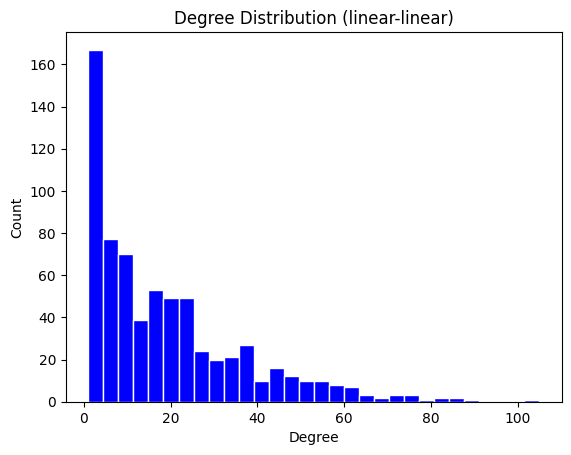

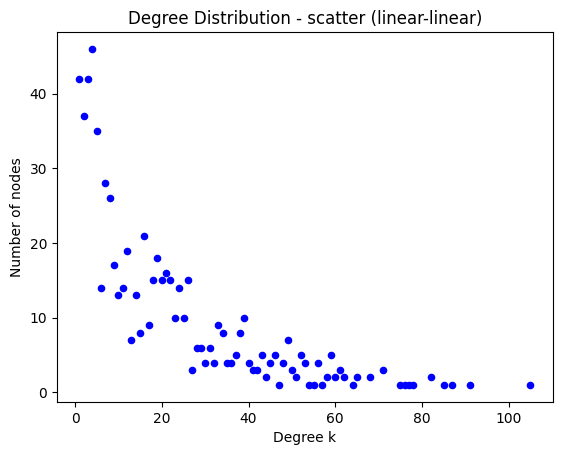

In [32]:
# Linear-linear Histogram Plot
plt.figure()
plt.hist(degrees, bins=30, color= "blue", edgecolor= "white")
plt.xlabel("Degree")
plt.ylabel("Count")
plt.title("Degree Distribution (linear-linear)")
plt.show()

# linear-linear scatter plot
plt.figure()
plt.scatter(k_values, freq_values, color="blue", s=20)
plt.xlabel("Degree k")
plt.ylabel("Number of nodes")
plt.title("Degree Distribution - scatter (linear-linear)")
plt.show()


### Linear-Linear Histogram Plot:

We observe a tall spike around degrees 0 and 10 , later when degree increases, bars getting shorter very fast, and the last visible bar around degree 90–105 is barely there. This shows us;

The distribution is very right-skewed which means most of the fields (nodes) have few connections.

few nodes with degree 60–105 are squashed into the baseline, which means the hubs are invisible.

## Log-log Scale

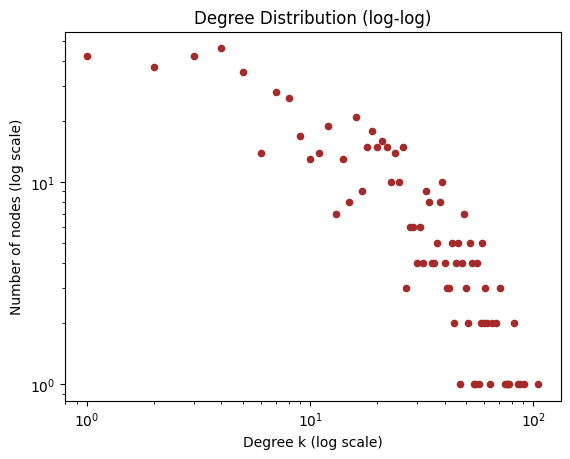

In [10]:
#  Log-log scatter plot
plt.figure()
plt.scatter(k_values, freq_values, color="brown", s=20)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Degree k (log scale)")
plt.ylabel("Number of nodes (log scale)")
plt.title("Degree Distribution (log-log)")
plt.show()

### Log-log Scatter Plot

We can see a clear roughly linear,descending cloud of points from top left to bottom right:

The distribution of straight line on log-log shows us the similar patterns as in power-law distribution. What our distribution means that not perfectly linear, but clearly trending downward in a log-linear way.

It is very scale-free pattern that typical of real-world networks. This means there is no "typical" degree where every scale has some nodes.

The few very high-degree nodes are now clearly visible as the points on the bottom right, which were invisible on the linear plots.

Comparing the plots log-log scale is suitable more than linear-linear scale for my network. While linear-linear scale plots compress the high-degree tail to invisibility, log-log scale reveal the long-tailed, heavy-tailed structure of the degree distribution. A roughly linear trend in the log-log scatter is consistent with a power-law-like distribution, typical of real-world networks.

# Q4
- What is the degree assortativity of the network?

- How do you interpret it?

In [11]:
assortativity = G.assortativity_degree()
print(f"Degree assortativity: {assortativity: .4f}")

Degree assortativity:  0.2448


The **assortativity degree** is **0.24** which is positive and mildly assortative. Therefore, it means high-degree fields tend to connect to other high-degree fields, and low-degree specialized fields tend to connect to other low-degree specialized fields.

This makes sense for our network, as Wikipedia pages about related fields tend to use similar vocabulary and thus share more connections.

# Q5
- Using any community detection method, does the network have a community structure?

- Do the detected communities make sense? Discuss.
*Note: the popular Louvain method only works for undirected graphs.

### Louvain Method

Since my network is undirected, we will use Louvain method for using any community detection method

In [31]:
ig.set_random_number_generator(random.Random(32))
partition = G.community_multilevel() #louvain 

print(f"Modularity: {partition.modularity}") # modularity
print(f"Number of communities: {len(partition)}") # number of communities
print(f"Community sizes: {partition.sizes()}") # size of each community



Modularity: 0.6166856394579596
Number of communities: 15
Community sizes: [145, 30, 109, 65, 64, 75, 106, 2, 26, 34, 19, 3, 4, 3, 2]


We obtain 15 clusters and size minimum from 2 to maximum 145.

The **modularity** that gives us the idea of how good is the partition, and it is **0.62**. The number states that the network has clear and meaningful community structure.

### Graph of the community

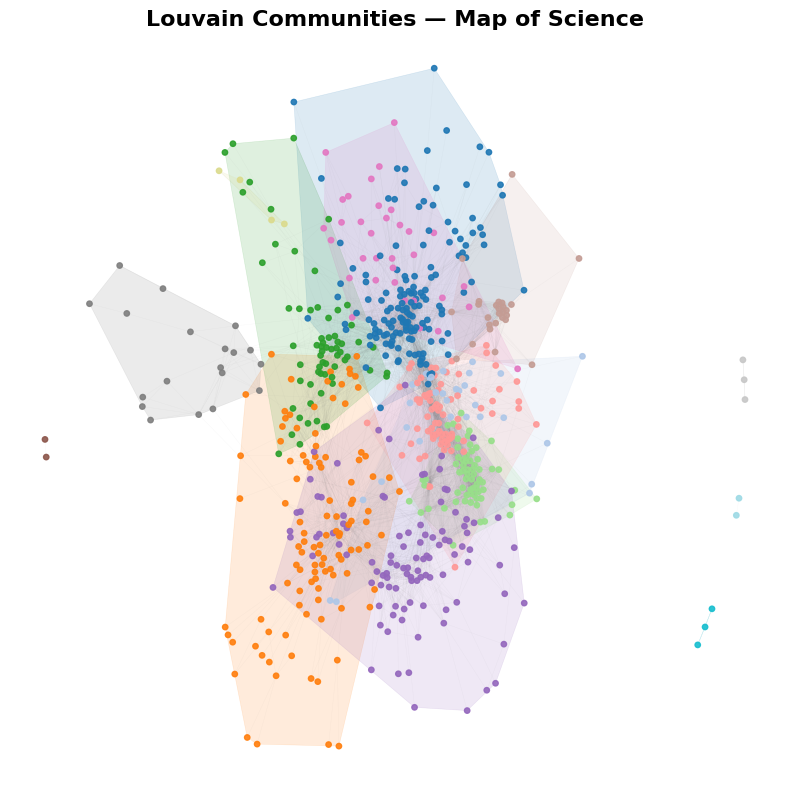

In [54]:
layout = G.layout("fr")
coords = np.array(layout.coords)
membership = partition.membership
n_comm = len(set(membership))
palette = plt.cm.tab20(np.linspace(0, 1, n_comm))

fig, ax = plt.subplots(figsize=(8, 8))


for comm_id in range(n_comm):
    idx = [i for i, m in enumerate(membership) if m == comm_id]
    comm_coords = coords[idx]
    if len(comm_coords) >= 3:
        try:
            hull = ConvexHull(comm_coords)
            pts = comm_coords[hull.vertices]
            poly = Polygon(pts, closed=True,
                           facecolor=palette[comm_id], alpha=0.15,
                           edgecolor=palette[comm_id], linewidth=0.4)
            ax.add_patch(poly)
        except:
            pass

for edge in G.es:
    s, t = edge.source, edge.target
    ax.plot([coords[s,0], coords[t,0]], [coords[s,1], coords[t,1]],
            color='gray', alpha=0.06, linewidth=0.3, zorder=1)

node_colors = [palette[m] for m in membership]
ax.scatter(coords[:,0], coords[:,1], c=node_colors, s=15, zorder=3, alpha=0.9)

ax.set_axis_off()
ax.set_title('Louvain Communities — Map of Science', fontsize=16, fontweight='bold')
ax.set_xlabel('Each shaded region = one detected community', fontsize=11, color='gray')
plt.tight_layout()
plt.show()

## True `Class` Column

In [14]:
# True `Class` Column
df = pd.DataFrame({
    "Class": G.vs["Class"],
    "Community": partition.membership
})

print(pd.crosstab(df["Class"], df["Community"]))

Community   0   1   2   3   4   5   6   7   8   9   10  11  12  13
Class                                                             
Applied     17  22  16  13   1  11  12   2   0   0   0   0   0   0
Formal       6  82  13   4  63   4   0   0  20   1   0   0   0   0
Natural      9   6  39   5   1  87   1   0   2  16   1   2   2   0
Social     115   3  44  49   0   5   0   0   4   2   2   2   1   2


Louvain method found **15 communities**, but there are only **4 true classes** (Applied, Formal, Natural, Social).

Some communities are pure or near–pure which are corresponding to one class, some of them are dominant-mixes where one class dominates, and some are smaller specialized communities which tend to be narrower sub-topics within a class.

For example,

Pure or near-pure are:

-   Community 4 by having 63 Formal, 1 Applied and 1 Natural; pure formal sciences cluster; probably math, logic, theoretical CS.

-   Others are:

    -   Community 1 being a near-pure Formal sciences cluster (82 Formal out of 113 nodes)

    -   Community 5 being a near-pure Natural sciences cluster (87 Natural out of 107 nodes)


Dominant-mixed are:

-   Community 0 by having 115 Social, 17 Applied, 9 Natural, 6 Formal; dominantly Social, but big and mixed. This is the largest community (147 nodes) and probably captures broad social/economic topics that touch many fields.
-   and others are:

    -   Community 2 (Social/Natural-mixed: 44 Social, 39 Natural)

    -   Community 3 (Social-dominant: 49 Social out of 71 nodes)


Specialized are:

-  Communities 6 through 14 (all small, ranging from 2 to 26 nodes)


## Comparing different communities

In [15]:
# convert Class labels to numeric
classes = G.vs["Class"]
unique_classes = list(set(classes))
class_numeric = [unique_classes.index(c) for c in classes]

nmi = ig.compare_communities(class_numeric, partition.membership, method="nmi")
print(f"NMI: {nmi:.4f}")

NMI: 0.3362


The **NMI** is **0.33**. This shows that the detected communities and the true classes agree somewhat, but the agreement is not very strong.The reason the NMI is not high is that Louvain found too many communities compared to the true classes. Louvain found 15 communities but the Class attribute only has 4 categories. The cross-tab table shows that some communities match one class clearly, while others are mixed. For example, some communities like community 4 and 5 are almost pure (mostly one class), while others like community 0 are dominant-mixed with several classes together. Overall, the communities do make sense. They capture the structure of the scientific fields but at a finer level than the 4 broad classes.

Lastly, I put some example communities and listing their member fields.

-   first 15 fields in community 5

-   first 15 fields in community 4

In [16]:
# first 15 fields in community 5 (near-pure Natural)
print([G.vs["name"][i] for i, m in enumerate(partition.membership) if m == 5][:15])

# first 15 fields in community 4 (pure Formal)
print([G.vs["name"][i] for i, m in enumerate(partition.membership) if m == 4][:15])

['Architectural engineering', 'Astronomy', 'Building science', 'Ceramic engineering', 'Environmental science', 'Materials science', 'Nuclear engineering', 'Nuclear technology', 'Optics', 'Polymer science', 'Space exploration', 'Computational fluid dynamics', 'Mathematical physics', 'Quantum field theory', 'Statistical mechanics']
['Applied mathematics', 'Affine geometry', 'Algebraic geometry', 'Algebraic number theory', 'Algebraic topology', 'Analytic number theory', 'Applied mathematics', 'Approximation theory', 'Associative algebra', 'Block design', 'Complex analysis', 'Computational mathematics', 'Differential algebra', 'Differential geometry', 'Differential topology']


# Q6

-   Compute the degree and betweenness centrality node scores. Who are the most 5 important nodes in each case?

-   Are they the same?

-   What does this tell you about the structure of the network?

We already computed the degree in question 2.

Betweenness centrality is about how often does node sit on the shortest path between other pairs of nodes.

In [17]:
betweenness = G.betweenness()

# Top 5 by degree
degree_with_names = list(zip(G.vs["name"], degrees))
top5_degree = sorted(degree_with_names, key=lambda x: x[1], reverse=True)[:5]
print("Top 5 by degree:", top5_degree)

#Top 5 by betweenness
betw_with_names = list(zip(G.vs["name"], betweenness))
top5_betw = sorted(betw_with_names, key=lambda x: x[1], reverse=True)[:5]
print("Top 5 by betweenness:", top5_betw)

Top 5 by degree: [('School psychology', 105), ('Economics', 91), ('Cognitive science', 87), ('Algorithm', 85), ('Information science', 82)]
Top 5 by betweenness: [('Population biology', 17557.54542464049), ('Algorithm', 13318.513200081357), ('Economics', 12449.519429207761), ('School psychology', 11049.477617170134), ('Evolutionary psychology', 8681.348634429278)]


-   The **most 5 degree** are School psychology, Economics, Cognitive science, Algorithm, Information science.

-   The **most 5 betweenness** are Population biology, Algorithm, Economics, School psychology, Evolutionary psychology.

-   There are **three fields overlapping** : School psychology, Economics, and Algorithm.

-   **Only in degree** are: Cognitive science and Information science.

-   **Only in betweennes**s are : Population biology and Evolutionary psychology.

The **three** **overlapping** fields have **both many direct neighbors and sit on many shortest paths**. They're central in two senses at once.

The two fields that are **high degree but not high betweenness** which are Cognitive science and Information science have many neighbors but those neighbors are mostly within one densely connected region. They don't act as bridges between separate parts of the network.

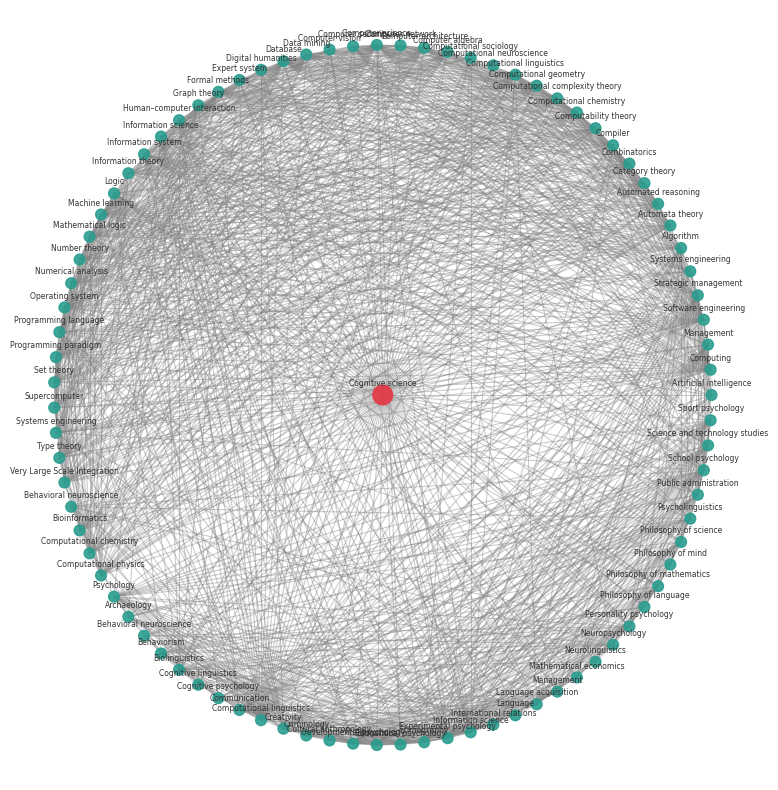

In [59]:
idx = G.vs.find(name='Cognitive science').index
ego = G.induced_subgraph(G.neighborhood(idx, order=1))
layout = ego.layout("star", center=ego.vs.find(name='Cognitive science').index)
coords = np.array(layout.coords)

node_colors = ['#E63946' if v['name'] == 'Cognitive science' else '#2A9D8F' for v in ego.vs]
node_sizes  = [200 if v['name'] == 'Cognitive science' else 60 for v in ego.vs]

fig, ax = plt.subplots(figsize=(8, 8))
for edge in ego.es:
    s, t = edge.source, edge.target
    ax.plot([coords[s,0], coords[t,0]], [coords[s,1], coords[t,1]],
            color='gray', alpha=0.4, linewidth=0.8, zorder=1)
ax.scatter(coords[:,0], coords[:,1], c=node_colors, s=node_sizes, zorder=2, alpha=0.9)
for i, v in enumerate(ego.vs):
    ax.annotate(v['name'], (coords[i,0], coords[i,1]),
                fontsize=5.5, ha='center', va='bottom',
                xytext=(0, 5), textcoords='offset points', color='#333333')
ax.set_axis_off()
plt.tight_layout()
plt.show()

The two fields that are **high betweenness but not high degree**. One of them is Population biology and it is the biggest number in betweenness but not one of the most 5 degrees. This means it has fewer neighbors, but its neighbors come from different parts of the network. So, it has a **bridge function** between distant fields.

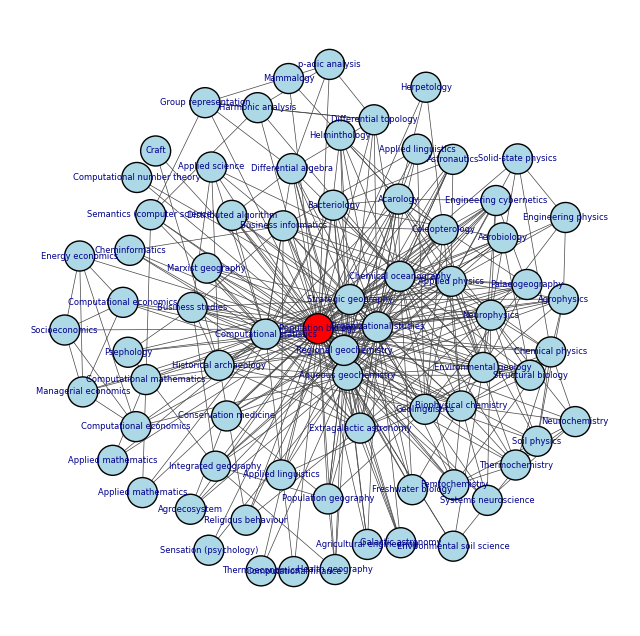

In [ ]:
pb_index = G.vs.find(name= "Population biology").index # getting the index of Population biology

pb_ego = G.induced_subgraph(G.neighborhood(pb_index, order =1)) #creating ego grapgh- node and its neighbors
colors = ["red" if v["name"] == "Population biology" else "lightblue"
          for v in pb_ego.vs]

#the plot
fig, ax= plt.subplots(figsize=(8,8))
ig.plot(pb_ego, target=ax,
        vertex_size=30,
        vertex_color=colors,
        vertex_label=pb_ego.vs["name"],
        vertex_label_size=6,
        vertex_label_color = "darkblue",
        edge_width = 0.5)
plt.show()


The other one is Evolutionary psychology. It also plays a similar bridge role like Population biology.

Neighbors: ['Strategic management', 'Evolution', 'Mutation', 'Population genetics', 'Psychology', 'Sociobiology', 'Applied psychology', 'Behavioral economics', 'Behaviorism', 'Clinical psychology', 'Cognitive psychology', 'Consumer behaviour', 'Creativity', 'Criminology', 'Cultural psychology', 'Developmental psychology', 'Economics', 'Educational psychology', 'Evolutionary economics', 'Evolutionary linguistics', 'Experimental psychology', 'Forensic psychology', 'Humanistic psychology', 'Industrial and organizational psychology', 'Language acquisition', 'Neuropsychology', 'Personality psychology', 'Political psychology', 'Psycholinguistics', 'Psychological testing', 'Psychology of religion', 'School psychology', 'Sport psychology']
Counter({'Social': 27, 'Natural': 5, 'Applied': 1})
Community: 0


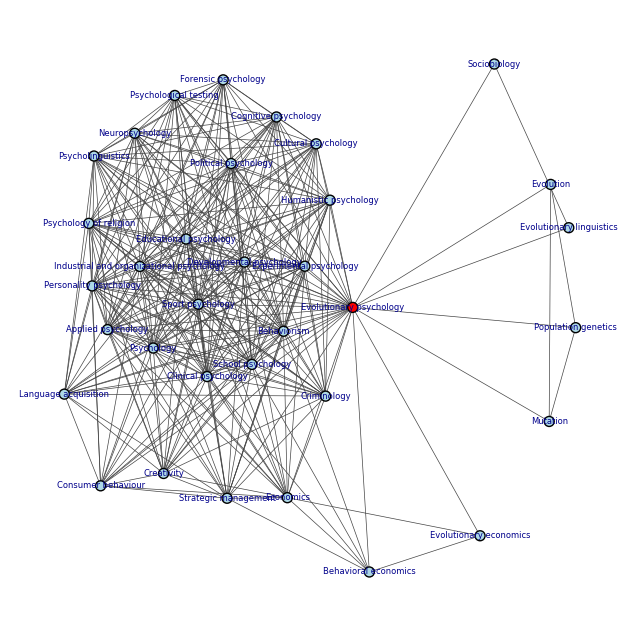

In [19]:
ep_index = G.vs.find(name = "Evolutionary psychology").index # for Evolutionary psychology

neighbors_ep = G.neighbors(ep_index)
print("Neighbors:", [G.vs[i]["name"] for i in neighbors_ep]) # neighbors of it

# What Classes do those neighbors belong to?
print(Counter([G.vs[i]["Class"] for i in neighbors_ep]))

# Louvain community membership
print("Community:", partition.membership[ep_index])

# ego plot of Evolutionary psychology
ep_ego = G.induced_subgraph(G.neighborhood(ep_index, order=1))
colors_ep = ["red" if v["name"] == "Evolutionary psychology" else "lightblue"
             for v in ep_ego.vs]

fig, ax = plt.subplots(figsize=(8, 8))
ig.plot(ep_ego, target=ax,
        vertex_size=10,
        vertex_color=colors_ep,
        vertex_label=ep_ego.vs["name"],
        vertex_label_size=6,
        vertex_label_color="darkblue",
        edge_width=0.5)
plt.show()

So, it bridges mainly within the psychology cluster but has direct links to evolutionary biology, evolutionary economics, and psycholinguistics.

### Structure of the network

The comparison between degree and betweenness centrality reveals that the Map of Science has a **heterogeneous, modular structure with a few key bridge nodes**.

The network is not simply organized around a single core. Instead, it has **dense clusters** that communities of related fields like formal sciences, natural sciences, social sciences are relatively well connected internally but only loosely connected to each other. This explains why degree and betweenness don't always agree:

-   **High degree and high betweenness** such as *Economics*, *Algorithm*, *School psychology*: these fields are universal. They have many neighbors and those neighbors span different communities. They are the true "hubs" of the network in every sense.

-   **High degree and low betweenness** such as *Cognitive science*, *Information science* : these fields have many connections, but they are concentrated within one dense region. They are local hubs, not global connectors. This is a hallmark of modular and clustered network structure.

-   **Low degree and high betweenness** such as *Population biology*, *Evolutionary psychology* : these are **structural bridges**. They are fields with few neighbors but whose neighbors come from very different parts of the network. Without them, the network would fragment into more isolated communities.

Therefore, the network pattern is consistent with a small-world and modular network, meaning that tightly-knit communities of related scientific fields, joined together by a small number of interdisciplinary bridge fields. The network is not random, and centrality alone would miss this structure.


# Q7

-   Test whether the clustering coefficient of your network can be statistically explained by the configuration model.

### Real clustering coefficient

In [20]:
# Real clustering coefficient
real_trans = G.transitivity_undirected()
print(f"Real clustering coefficient: {real_trans: .4f}")

Real clustering coefficient:  0.4693


### Configuration Model
Generating 1000 configuration model networks and computing their clustering

In [21]:
trans_config_model = [
    ig.Graph.Degree_Sequence(degrees, method="vl").transitivity_undirected()
    for _ in range(1000)
]
#print(f"transitivity configuration model: {trans_config_model}")

### Plotting null distribution and real value

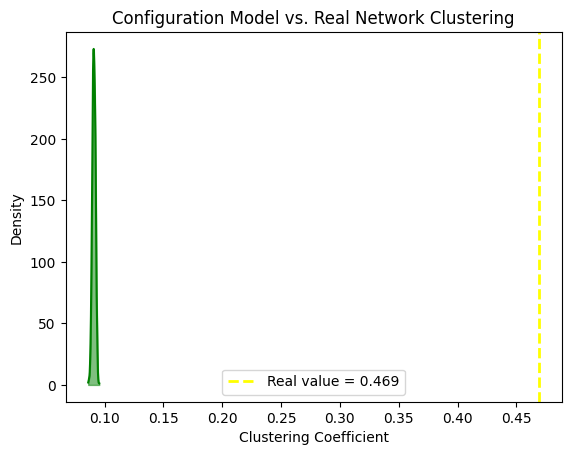

In [22]:
x = np.linspace(min(trans_config_model), max(trans_config_model), 300)
kde = gaussian_kde(trans_config_model)

plt.figure()
plt.fill_between(x, kde(x), alpha= 0.5, color="green")
plt.plot(x, kde(x), color ="green")
plt.axvline(real_trans, color="yellow", linestyle="--", linewidth=2,
            label = f"Real value = {real_trans:.3f}")
plt.xlabel("Clustering Coefficient")
plt.ylabel("Density")
plt.title("Configuration Model vs. Real Network Clustering")
plt.legend()
plt.show()

### P-value
p-value (assuming normal distribution of null values)

In [34]:
mu = np.mean(trans_config_model)
sigma = np.std(trans_config_model)
p_value= norm.pdf(real_trans, loc=mu, scale=sigma)

print(f"Mean of configuration model: {mu:.4f}")
print(f"SD of configuration model:   {sigma:.6f}")
print(f"P-value:              {p_value}")

Mean of configuration model: 0.0910
SD of configuration model:   0.001367
P-value:              0.0


The real clustering coefficient of the MapOfScience network is **0.47**, whereas the configuration model which we did by 1000 realizations with the same degree sequence that produces a **mean clustering** of only **0.09** and with **0.0014** standard deviation. The p-value is effectively **0**, this means the real clustering is statistically impossible under the configuration model. Therefore, the clustering coefficient **cannot** be explained by the degree distribution alone. The network has significantly more triangular structure than expected by chance. This is consistent with the strong community structure that we found in Q5, where scientific fields form tightly-knit disciplinary clusters.